In [1]:
import perturb_lib as plib

In [14]:
import numpy as np
import pandas as pd

In [3]:
import inspect
import os
import sys

LPM_STYLE_ROOT = "/home/icb/olga.novitskaia/lpm_style"

for mod in [m for m in list(sys.modules) if m == "perturb_lib" or m.startswith("perturb_lib.")]:
    del sys.modules[mod]

sys.path = [LPM_STYLE_ROOT] + [p for p in sys.path if "perturblib" not in p and p != LPM_STYLE_ROOT]
os.chdir(LPM_STYLE_ROOT)

import perturb_lib as plib
from perturb_lib.models.collection.lpm import LPM
import perturb_lib.models.access as model_access

assert "lpm_style" in inspect.getfile(plib), f"perturb_lib resolved to {inspect.getfile(plib)}"
assert "lpm_style" in inspect.getfile(LPM), f"LPM resolved to {inspect.getfile(LPM)}"

model_access.model_catalogue["LPM"] = LPM

print("perturb_lib  :", inspect.getfile(plib))
print("LPM class    :", inspect.getfile(LPM))
print("registered LPM is local fork:", model_access.model_catalogue["LPM"] is LPM)

perturb_lib  : /home/icb/olga.novitskaia/lpm_style/perturb_lib/__init__.py
LPM class    : /home/icb/olga.novitskaia/lpm_style/perturb_lib/models/collection/lpm.py
registered LPM is local fork: True


In [4]:
import torch
from pathlib import Path

RESULTS_ROOT = Path(LPM_STYLE_ROOT) / ".plib_cache/results/lpm_modified"

candidate_ckpts = sorted(RESULTS_ROOT.glob("LPM_*/seed_*/model.pt"), key=lambda p: p.stat().st_mtime)
if not candidate_ckpts:
    raise FileNotFoundError(f"No model.pt under {RESULTS_ROOT}. Run training first.")
MODEL_PATH = candidate_ckpts[-1]
print("Most recent checkpoint:", MODEL_PATH)
print("Modified:", Path(MODEL_PATH).stat().st_mtime)

raw = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
if isinstance(raw, tuple):
    saved_id, saved_args, saved_state = raw
    print("model_id     :", saved_id)
    print("model_args   :", {k: v for k, v in saved_args.items() if k != "lightning_trainer_pars"})
    print("state keys   :", len(saved_state))
    print("has dataset_embedding_layer.weight:", "dataset_embedding_layer.weight" in saved_state)
    if "predictor.0.weight" in saved_state:
        print("predictor.0.weight shape:", tuple(saved_state["predictor.0.weight"].shape))
else:
    print("Pickled full ModelMixin object; type:", type(raw).__name__)

Most recent checkpoint: /home/icb/olga.novitskaia/lpm_style/.plib_cache/results/lpm_modified/LPM_fa51c10d14c24fd9/seed_13/model.pt
Modified: 1777539696.0
model_id     : LPM
model_args   : {'optimizer_name': 'AdamW', 'learning_rate': 0.002, 'learning_rate_decay': 0.97, 'num_layers': 2, 'hidden_dim': 256, 'dropout': 0.1, 'batch_size': 16384, 'embedding_dim': 128, 'num_workers': 6, 'step_checkpoint_every_n_steps': 1000, 'step_checkpoint_save_top_k': 10}
state keys   : 18
has dataset_embedding_layer.weight: True
predictor.0.weight shape: (256, 768)


In [5]:
import torch.nn as nn
from perturb_lib.models.access import load_model as _load_model

# `plib.load_trained_model` calls `LPM.load_state_dict`, which in this fork rebuilds
# the *Embedding* layers from `from_pretrained` but DOES NOT recreate the two
# `nn.Linear(1, embedding_dim)` continuous-feature projections (log_dose_layer,
# time_layer). Those are only ever built inside `fit()`, so at load time they're
# still None and `super().load_state_dict()` flags their keys as "Unexpected".
# Workaround: instantiate the model by hand, pre-create the missing Linear layers,
# then call `load_state_dict`. No edits to the model code itself.
raw = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
if isinstance(raw, tuple):
    saved_id, saved_args, saved_state = raw
    assert saved_id == "LPM", f"Expected model_id='LPM', got {saved_id!r}"
    model = _load_model("LPM", saved_args)
    if "log_dose_layer.weight" in saved_state and model.log_dose_layer is None:
        model.log_dose_layer = nn.Linear(1, model.embedding_dim)
    if "time_layer.weight" in saved_state and model.time_layer is None:
        model.time_layer = nn.Linear(1, model.embedding_dim)
    # NOTE: the local LPM override of `load_state_dict` does not `return` what
    # `super()` returns, so we cannot rely on `_IncompatibleKeys`. Compute the
    # diff manually before/after.
    saved_keys = set(saved_state.keys()) - {
        "context_symbols", "perturb_symbols", "readout_symbols", "dataset_symbols",
    }
    model.load_state_dict(saved_state, strict=False)
    model_keys = set(model.state_dict().keys()) - {
        "context_symbols", "perturb_symbols", "readout_symbols", "dataset_symbols",
    }
    missing_keys = sorted(model_keys - saved_keys)
    unexpected_keys = sorted(saved_keys - model_keys)
    print("missing keys    :", missing_keys)
    print("unexpected keys :", unexpected_keys)
    if missing_keys or unexpected_keys:
        raise RuntimeError("State dict still incompatible — see lists above.")
else:
    model = raw

model.eval()
print()
print("Loaded model class :", type(model).__name__)
print("Loaded class file  :", inspect.getfile(type(model)))
print("vocab present      :", model.vocab is not None)
if model.vocab is not None:
    print("dataset symbols    :", len(model.vocab.dataset_vocab))
    print("context symbols    :", len(model.vocab.context_vocab))
    print("perturb symbols    :", len(model.vocab.perturb_vocab))
    print("readout symbols    :", len(model.vocab.readout_vocab))

missing keys    : []
unexpected keys : []

Loaded model class : LPM
Loaded class file  : /home/icb/olga.novitskaia/lpm_style/perturb_lib/models/collection/lpm.py
vocab present      : True
dataset symbols    : 10
context symbols    : 130
perturb symbols    : 37441
readout symbols    : 43499


In [6]:
import torch
print("=== NaN/Inf scan over loaded model parameters ===")
bad = []
for name, p in model.named_parameters():
    n_nan = torch.isnan(p).sum().item()
    n_inf = torch.isinf(p).sum().item()
    if n_nan or n_inf:
        bad.append((name, tuple(p.shape), n_nan, n_inf, p.numel()))
        print(f"  {name:40s} shape={tuple(p.shape)}  NaN={n_nan}  Inf={n_inf}  total={p.numel()}")
print()
print(f"Layers with bad values : {len(bad)} / {sum(1 for _ in model.named_parameters())}")
if not bad:
    print("All parameters finite (model is fine; check inputs/preprocessing).")
else:
    print("First-corrupted hypothesis:")
    print("  - if ONLY perturb_embedding_layer → empty-bag NaN (mode=mean/sum on empty list)")
    print("  - if log_dose_layer or time_layer present → check raw log_dose/time values")
    print("  - if predictor.* widespread → loss/grad blowup (bf16 + LR too high)")

=== NaN/Inf scan over loaded model parameters ===

Layers with bad values : 0 / 14
All parameters finite (model is fine; check inputs/preprocessing).


In [7]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np
from sklearn.decomposition import PCA

In [8]:
df_pert = model.vocab.perturb_vocab.to_pandas()
pert_embeddings = model.perturb_embedding_layer.weight.numpy().astype(np.float32)
df_pert['lpm_style_embeddings'] = pert_embeddings.tolist()


df_context = model.vocab.context_vocab.to_pandas()
context_embeddings = model.context_embedding_layer.weight.numpy().astype(np.float32)
df_context['lpm_style_embeddings'] = context_embeddings.tolist()

df_readout = model.vocab.readout_vocab.to_pandas()
readout_embeddings = model.readout_embedding_layer.weight.numpy().astype(np.float32)
df_readout['lpm_style_embeddings'] = readout_embeddings.tolist()

In [9]:
os.makedirs('./lpm_style_embeddings_epoch_5/')

In [10]:
df_pert.to_pickle("./lpm_style_embeddings_epoch_5/df_pert.pkl")
df_context.to_pickle("./lpm_style_embeddings_epoch_5/df_context.pkl")
df_readout.to_pickle("./lpm_style_embeddings_epoch_5/df_readout.pkl")

In [12]:
df_pert

,symbol,code,lpm_style_embeddings
0,Control,0,"[-4.827737939194776e-05, 6.416104588424787e-05..."
1,1000,1,"[0.0805216059088707, -0.22724835574626923, -0...."
2,10000456,2,"[0.060999833047389984, 0.07012023031711578, -0..."
3,10000860,3,"[-0.050012487918138504, -0.034858088940382004,..."
4,100016,4,"[0.03504176437854767, -0.01943945325911045, -0..."
...,...,...,...
37436,9995621,37436,"[0.02433454431593418, -0.056288644671440125, -..."
37437,9995890,37437,"[-0.009366903454065323, -0.019266339018940926,..."
37438,9996409,37438,"[-0.09981988370418549, 0.05748565122485161, 0...."
37439,9998837,37439,"[-0.037708837538957596, 0.018672198057174683, ..."


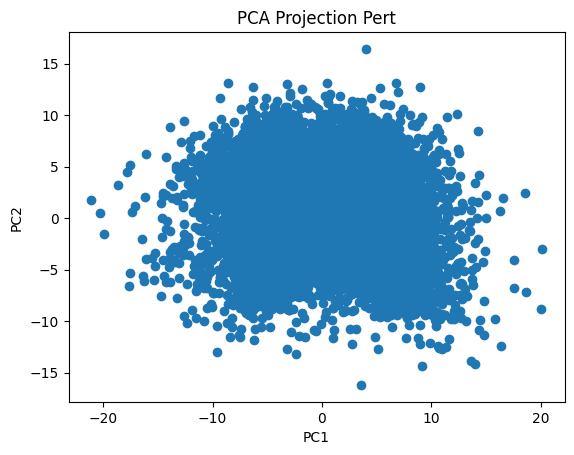

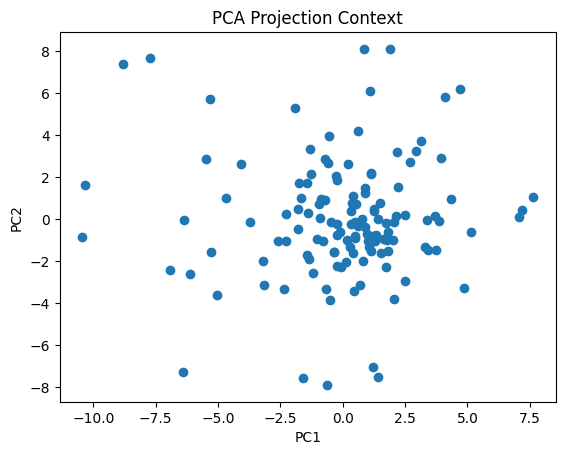

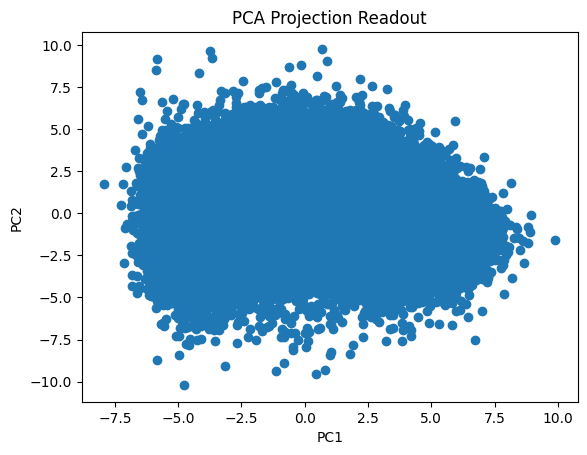

In [11]:
# X shape: (n_samples, n_features)
X = pert_embeddings#[:100]

# Optional: check for NaNs first
if np.isnan(X).any():
    raise ValueError("X contains NaNs")

X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection Pert")
plt.show()

# X shape: (n_samples, n_features)
X = context_embeddings#[:100]

# Optional: check for NaNs first
if np.isnan(X).any():
    raise ValueError("X contains NaNs")

X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection Context")
plt.show()








# X shape: (n_samples, n_features)
X = readout_embeddings#[:100]

# Optional: check for NaNs first
if np.isnan(X).any():
    raise ValueError("X contains NaNs")

X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection Readout")

plt.show()